# Lab 2: Multi-Layer Perceptrons, Backpropagation, and Evaluation

**Module:** Artificial Intelligence  
**Topic:** Neural Networks – Part 2  

## Learning Objectives
By the end of this lab, you will be able to:
>1. Implement a Multi-Layer Perceptron (MLP) with sigmoid activation from scratch
>2. Train the MLP using the backpropagation algorithm
>3. Apply data normalisation for neural network training
>4. Classify the Iris dataset using your MLP implementation
>5. Compute and interpret a confusion matrix
>6. Evaluate model performance using cross-validation
>7. Apply vector hashing for text classification


## Background

### From Perceptrons to MLPs

In Lab 1, we saw that single-layer perceptrons can only solve linearly separable problems. To solve more complex problems like XOR, we need **Multi-Layer Perceptrons (MLPs)** with hidden layers.

### The Sigmoid Activation Function

Unlike the step function, the **sigmoid function** is differentiable, which allows us to use gradient-based training:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

Its derivative (needed for backpropagation) is:

$$\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))$$

### The Backpropagation Algorithm

Backpropagation trains MLPs by:

1. **Forward pass:** Compute outputs layer by layer
2. **Compute error:** Compare output to expected value
3. **Backward pass:** Propagate error gradients back through the network
4. **Update weights:** Adjust weights to reduce error

### Data Normalisation

Neural networks work best when input features are normalised to a consistent range (e.g., [0, 1] or [-1, 1]). This prevents features with larger values from dominating the learning process.

## Setup
Import the necessary libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
# Set random seed for reproducibility
np.random.seed(42)
# Configure matplotlib
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["font.size"] = 12
print("Libraries loaded successfully!")

Libraries loaded successfully!


## Exercise 1: Implement an MLP Class

Build an MLP with:
- Configurable number of input, hidden, and output neurons
- Sigmoid activation function
- Backpropagation training

In [3]:
class MLP:
    """
    Multi-Layer Perceptron with one hidden layer.
    Uses sigmoid activation and backpropagation.
    """

    def __init__(self, n_inputs, n_hidden, n_outputs, learning_rate=0.1):
        """
        Initialise the MLP.

        Parameters:
        -----------
        n_inputs : int
            Number of input features
        n_hidden : int
            Number of hidden neurons
        n_outputs : int
            Number of output neurons
        learning_rate : float
            Learning rate for weight updates
        """
        self.learning_rate = learning_rate

        # Input to hidden layer weights (weights_ih) and biases (bias_h)
        self.weights_ih = np.random.uniform(-0.5, 0.5, (n_inputs, n_hidden))
        self.bias_h = np.random.uniform(-0.5, 0.5, n_hidden)

        # Hidden to output layer weights (weights_ho) and biases (bias_o)
        # TODO: add code here for weights_ho and bias_o
        ## Hint: see code for weights_ih and bias_h above
        self.weights_ho = np.random.uniform(-0.5, 0.5, (n_hidden, n_outputs))
        self.bias_o = np.random.uniform(-0.5, 0.5, n_outputs)

    def sigmoid(self, x):
        """Sigmoid activation function."""
        # TODO: Implement sigmoid
        ## Hint: see Lab 1
        # Clip to avoid overflow in exp
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def sigmoid_derivative(self, x):
        """Derivative of sigmoid: σ'(x) = σ(x) * (1 - σ(x))."""
        # TODO: Implement sigmoid derivative
        ## Hint: see Lab 1
        s = self.sigmoid(x)
        return s * (1 - s)

    def forward(self, X):
        """
        Forward pass through the network.

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_inputs)
            Input data

        Returns:
        --------
        array : Output activations
        """
        # TODO: code this entire method
        ## Hint: see Lab 1

        # Input to hidden layer
        self.z_h = np.dot(X, self.weights_ih) + self.bias_h
        self.a_h = self.sigmoid(self.z_h)

        # Hidden to output
        self.z_o = np.dot(self.a_h, self.weights_ho) + self.bias_o
        self.a_o = self.sigmoid(self.z_o)

        return self.a_o

    def backward(self, X, y):
        """
        Backward pass (backpropagation).

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_inputs)
            Input data
        y : array-like, shape (n_samples, n_outputs)
            Target outputs
        """
        # TODO: code this entire method
        ## Hint: see Lab 1
        m = X.shape[0]  # Number of samples

        # Output layer error
        output_error = y - self.a_o
        output_delta = output_error * self.sigmoid_derivative(self.z_o)

        # Hidden layer error
        hidden_error = np.dot(output_delta, self.weights_ho.T)
        hidden_delta = hidden_error * self.sigmoid_derivative(self.z_h)

        # Update weights and biases
        self.weights_ho += self.learning_rate * np.dot(self.a_h.T, output_delta) / m
        self.bias_o += self.learning_rate * np.mean(output_delta, axis=0)

        self.weights_ih += self.learning_rate * np.dot(X.T, hidden_delta) / m
        self.bias_h += self.learning_rate * np.mean(hidden_delta, axis=0)

    def train(self, X, y, epochs, verbose=True):
        """
        Train the network.

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_inputs)
            Training inputs
        y : array-like, shape (n_samples, n_outputs)
            Training targets
        epochs : int
            Number of training epochs
        verbose : bool
            Print progress if True

        Returns:
        --------
        list : Training loss history
        """
        losses = []

        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Compute loss (Mean Squared Error)
            loss = np.mean((y - output) ** 2)
            losses.append(loss)

            # Backward pass
            self.backward(X, y)

            if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch}: Loss = {loss:.6f}")

        return losses

    def predict(self, X):
        """
        Make predictions.

        Returns the class with highest output activation.
        """
        output = self.forward(X)
        return np.argmax(output, axis=1)


print("MLP class defined successfully!")

MLP class defined successfully!


## Exercise 2: Test the MLP on XOR  

Before using the MLP on real data, verify it works on XOR (from Lab 1).

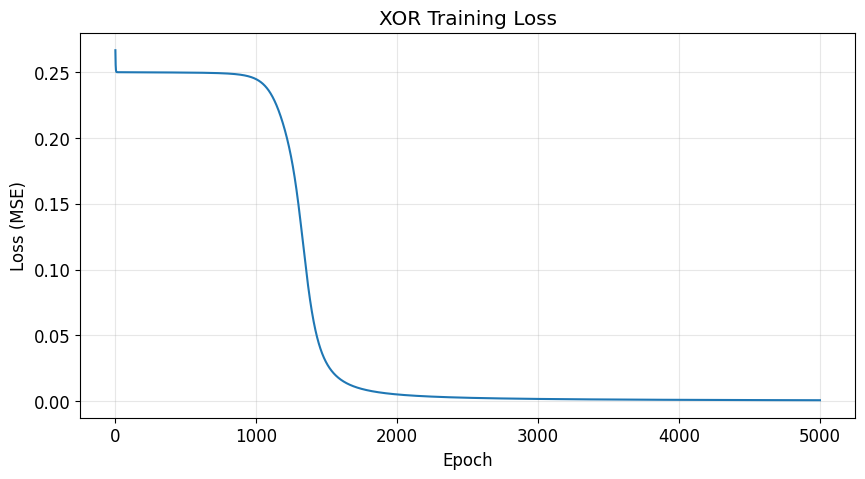


XOR Predictions:
--------------------------------------------------
Input: [0 0] -> Output: 0.0251 -> Rounded: 0 (Expected: 0) ✓
Input: [0 1] -> Output: 0.9708 -> Rounded: 1 (Expected: 1) ✓
Input: [1 0] -> Output: 0.9770 -> Rounded: 1 (Expected: 1) ✓
Input: [1 1] -> Output: 0.0241 -> Rounded: 0 (Expected: 0) ✓


In [4]:
# Define XOR data
# TODO: add code here to define XOR data
## Hint: see Lab 1
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
y_xor = np.array([[0],
                  [1],
                  [1],
                  [0]])

# Create and train MLP
np.random.seed(42)
mlp_xor = MLP(n_inputs=2, n_hidden=4, n_outputs=1, learning_rate=2.0)
losses_xor = mlp_xor.train(X_xor, y_xor, epochs=5000, verbose=False)
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses_xor)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('XOR Training Loss')
plt.grid(True, alpha=0.3)
plt.show()
# Test predictions
print("\nXOR Predictions:")
print("-" * 50)

for i in range(len(X_xor)):
 output = mlp_xor.forward(X_xor[i:i+1])
 rounded = round(output[0][0])
 correct = "✓" if rounded == y_xor[i][0] else "✗"
 print(f"Input: {X_xor[i]} -> Output: {output[0][0]:.4f} -> Rounded: {rounded} (Expected: {y_xor[i][0]}) {correct}")

## Exercise 3:  Load and Prepare the Iris Dataset

The Iris dataset contains 150 samples of iris flowers with:  

- 4 features: sepal length, sepal width, petal length, petal width
- 3 classes: Setosa, Versicolor, Virginica

### Task 3.1: Load and Explore the Data

In [5]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
print("Iris Dataset Overview")
print("=" * 50)
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names: {iris.feature_names}")
print(f"Target names: {iris.target_names}")
print(f"\nClass distribution: {np.bincount(y)}")

Iris Dataset Overview
Features shape: (150, 4)
Target shape: (150,)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']

Class distribution: [50 50 50]


### Task 3.2: Normalise the Data

Normalise features to [0, 1] range for better neural network performance

In [6]:
# Normalise features to [0, 1]
scaler = MinMaxScaler()
X_normalised = scaler.fit_transform(X)
print("Data Normalisation")
print("=" * 50)
print("Before normalisation:")
print(f" Min: {X.min(axis=0)}")
print(f" Max: {X.max(axis=0)}")
print("\nAfter normalisation:")
print(f" Min: {X_normalised.min(axis=0)}")
print(f" Max: {X_normalised.max(axis=0)}")

Data Normalisation
Before normalisation:
 Min: [4.3 2.  1.  0.1]
 Max: [7.9 4.4 6.9 2.5]

After normalisation:
 Min: [0. 0. 0. 0.]
 Max: [1. 1. 1. 1.]


### Task 3.3: One-Hot Encode the Targets

For multi-class classification with neural networks, we convert class labels to one-hot encoding:
- Class 0 → [1, 0, 0]
- Class 1 → [0, 1, 0]
- Class 2 → [0, 0, 1]

In [7]:
# One-hot encode targets
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))
print("One-Hot Encoding")
print("=" * 50)
print(f"Original y[:5]: {y[:5]}")
print(f"\nOne-hot y[:5]:")
print(y_onehot[:5])
print(f"\nEncoding: 0 → [1,0,0], 1 → [0,1,0], 2 → [0,0,1]")

One-Hot Encoding
Original y[:5]: [0 0 0 0 0]

One-hot y[:5]:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]

Encoding: 0 → [1,0,0], 1 → [0,1,0], 2 → [0,0,1]


### Task 3.4: Split into Training and Test Sets

In [8]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
 X_normalised, y_onehot, test_size=0.2, random_state=42, stratify=y
)
# Also keep original labels for evaluation
_, _, y_train_labels, y_test_labels = train_test_split(
 X_normalised, y, test_size=0.2, random_state=42, stratify=y
)
print("Train/Test Split")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Train/Test Split
Training set: 120 samples
Test set: 30 samples


## Exercise 4: Train the MLP on Iris

### Task 4.1: Create and Train the Network

Suggested architecture:
- 4 input neurons (one per feature)
- 8 hidden neurons
- 3 output neurons (one per class)

In [9]:
np.random.seed(42)
# Create MLP: 4 inputs, 8 hidden, 3 outputs, learning rate = 0.5
# TODO: add code here to create MLP
## Hint: see Exercise 2
mlp_iris = MLP(n_inputs=4, n_hidden=8, n_outputs=3, learning_rate=0.5)

print("Training MLP on Iris dataset...")
print("=" * 50)
# Train
losses_iris = mlp_iris.train(X_train, y_train, epochs=1000, verbose=True)

Training MLP on Iris dataset...
Epoch 0: Loss = 0.245520
Epoch 100: Loss = 0.212343
Epoch 200: Loss = 0.192939
Epoch 300: Loss = 0.160408
Epoch 400: Loss = 0.134717
Epoch 500: Loss = 0.121064
Epoch 600: Loss = 0.113445
Epoch 700: Loss = 0.108393
Epoch 800: Loss = 0.104507
Epoch 900: Loss = 0.101203
Epoch 999: Loss = 0.098243


### Task 4.2: Plot Training Loss

Visualise how the loss decreases during training

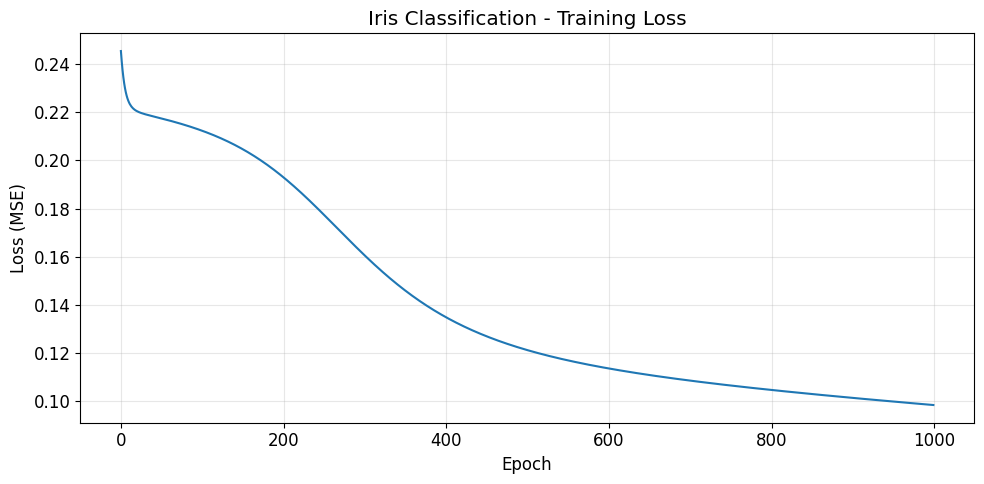

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(losses_iris)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Iris Classification - Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 4.3: Evaluate on Test Set

In [11]:
# Predictions
y_pred = mlp_iris.predict(X_test)
y_true = np.argmax(y_test, axis=1)
# Accuracy
accuracy = np.mean(y_pred == y_true)
print("Test Set Evaluation")
print("=" * 50)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Correct predictions: {np.sum(y_pred == y_true)}/{len(y_true)}")

Test Set Evaluation
Test Accuracy: 80.00%
Correct predictions: 24/30


## Exercise 5: Confusion Matrix (From Scratch)

A confusion matrix shows the counts of correct and incorrect predictions for each class.

For a binary classifier:

|                | **Predicted +** | **Predicted -** |
|----------------|:---:|:---:|
| **Actual +**   | TP  | FN  |
| **Actual -**   | FP  | TN  |

### Task 5.1: Implement Confusion Matrix

In [12]:
def compute_confusion_matrix(y_true, y_pred, n_classes):
    """
    Compute confusion matrix from scratch.

    Parameters:
    -----------
    y_true : array-like
    True class labels
    y_pred : array-like
    Predicted class labels
    n_classes : int
    Number of classes

    Returns:
    --------
    ndarray : Confusion matrix of shape (n_classes, n_classes)
    """
    cm = np.zeros((n_classes, n_classes), dtype=int)

    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1

    return cm
# Compute confusion matrix
cm = compute_confusion_matrix(y_true, y_pred, n_classes=3)
print("Confusion Matrix (from scratch)")
print("=" * 50)
print(cm)
print(f"\nRows = Actual, Columns = Predicted")
print(f"Diagonal = Correct predictions")

Confusion Matrix (from scratch)
[[10  0  0]
 [ 0  4  6]
 [ 0  0 10]]

Rows = Actual, Columns = Predicted
Diagonal = Correct predictions


### Task 5.2: Verify with sklearn

Compare your from-scratch implementation with sklearn's built-in function.

In [13]:
from sklearn.metrics import confusion_matrix as sklearn_cm, classification_report
# sklearn's confusion matrix (should match ours)
cm_sklearn = sklearn_cm(y_true, y_pred)
print("Verification with sklearn")
print("=" * 50)
print("Our confusion matrix:")
print(cm)
print("\nsklearn confusion matrix:")
print(cm_sklearn)
print(f"\nMatrices match: {np.array_equal(cm, cm_sklearn)}")
# Full classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=iris.target_names))

Verification with sklearn
Our confusion matrix:
[[10  0  0]
 [ 0  4  6]
 [ 0  0 10]]

sklearn confusion matrix:
[[10  0  0]
 [ 0  4  6]
 [ 0  0 10]]

Matrices match: True

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.40      0.57        10
   virginica       0.62      1.00      0.77        10

    accuracy                           0.80        30
   macro avg       0.88      0.80      0.78        30
weighted avg       0.88      0.80      0.78        30



### Task 5.3: Visualise the Confusion Matrix

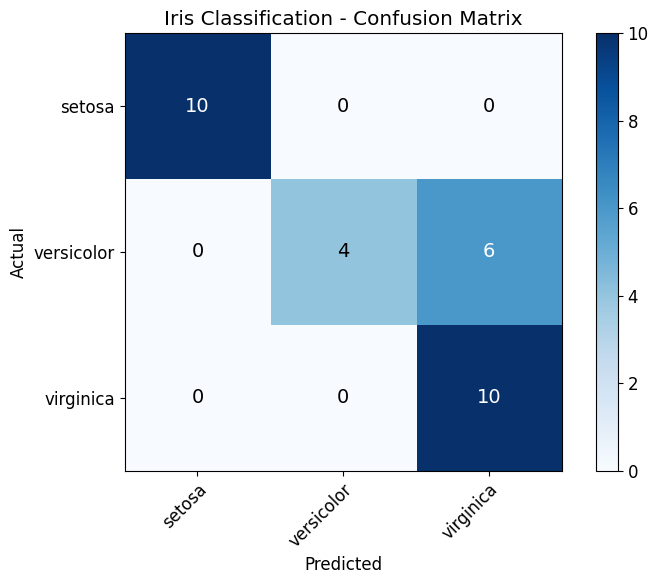

In [14]:
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    """
    Plot confusion matrix as a heatmap.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names,
           yticklabels=class_names,
           title=title,
           ylabel='Actual',
           xlabel='Predicted')

    # Rotate tick labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14)

    plt.tight_layout()
    return fig

# Plot
fig = plot_confusion_matrix(cm, iris.target_names, "Iris Classification - Confusion Matrix")
plt.show()

### Task 5.4: Compute Performance Metrics

From the confusion matrix, compute:  
- Accuracy = (TP + TN) / Total
- Precision (per class) = TP / (TP + FP)
- Recall / Sensitivity (per class) = TP / (TP + FN)

In [15]:
def compute_metrics(cm):
    """Compute accuracy, precision, and recall from confusion matrix."""
    n_classes = cm.shape[0]

    # Accuracy: sum of diagonal / total
    accuracy = np.trace(cm) / np.sum(cm)

    # Per-class precision and recall
    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)

    for i in range(n_classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp # Column sum minus TP
        fn = np.sum(cm[i, :]) - tp # Row sum minus TP

        precision[i] = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall[i] = tp / (tp + fn) if (tp + fn) > 0 else 0

    return accuracy, precision, recall
# Compute metrics
accuracy, precision, recall = compute_metrics(cm)
print("Performance Metrics")
print("=" * 50)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print(f"\nPer-class metrics:")
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12}")
print("-" * 39)
for i, name in enumerate(iris.target_names):
 print(f"{name:<15} {precision[i]*100:>8.2f}% {recall[i]*100:>8.2f}%")

Performance Metrics
Overall Accuracy: 80.00%

Per-class metrics:
Class           Precision    Recall      
---------------------------------------
setosa            100.00%   100.00%
versicolor        100.00%    40.00%
virginica          62.50%   100.00%


## Exercise 6: Compare with sklearn's MLPClassifier  

Verify your implementation by comparing with sklearn's built-in MLP.

**Note:** sklearn's MLPClassifier typically achieves higher accuracy because it includes:
- Better weight initialisation (Xavier/Glorot)
- Momentum to smooth gradient updates
- Adaptive learning rate
- L2 regularisation
- Softmax output with cross-entropy loss (optimal for classification)

Our simpler implementation demonstrates the core concepts but lacks these optimisations.  
sklearn also handles one-hot encoding internally when you pass class labels

In [16]:
# sklearn MLP
sklearn_mlp = MLPClassifier(
 hidden_layer_sizes=(8,), # One hidden layer with 8 neurons
 activation='logistic', # Sigmoid activation
 solver='sgd', # Stochastic gradient descent
 learning_rate_init=0.5,
 max_iter=1000,
 random_state=42
)
# Train (sklearn receives class labels, not one-hot)
sklearn_mlp.fit(X_train, y_train_labels)
# Evaluate
sklearn_pred = sklearn_mlp.predict(X_test)
sklearn_accuracy = accuracy_score(y_test_labels, sklearn_pred)
print("Comparison: Our MLP vs sklearn MLPClassifier")
print("=" * 50)
print(f"Our MLP Accuracy: {accuracy * 100:.2f}%")
print(f"sklearn MLP Accuracy: {sklearn_accuracy * 100:.2f}%")
print(f"\nsklearn typically achieves higher accuracy due to its optimisations.")

Comparison: Our MLP vs sklearn MLPClassifier
Our MLP Accuracy: 80.00%
sklearn MLP Accuracy: 96.67%

sklearn typically achieves higher accuracy due to its optimisations.


## Exercise 7: Cross-Validation

Use 10-fold cross-validation to get a more robust estimate of model performance.

10-Fold Cross-Validation Results
Fold scores: [1.         1.         1.         0.93333333 0.93333333 1.
 0.86666667 1.         1.         1.        ]

Mean accuracy: 97.33%
Standard deviation: 4.42%

95% confidence interval: 97.33% ± 8.67%


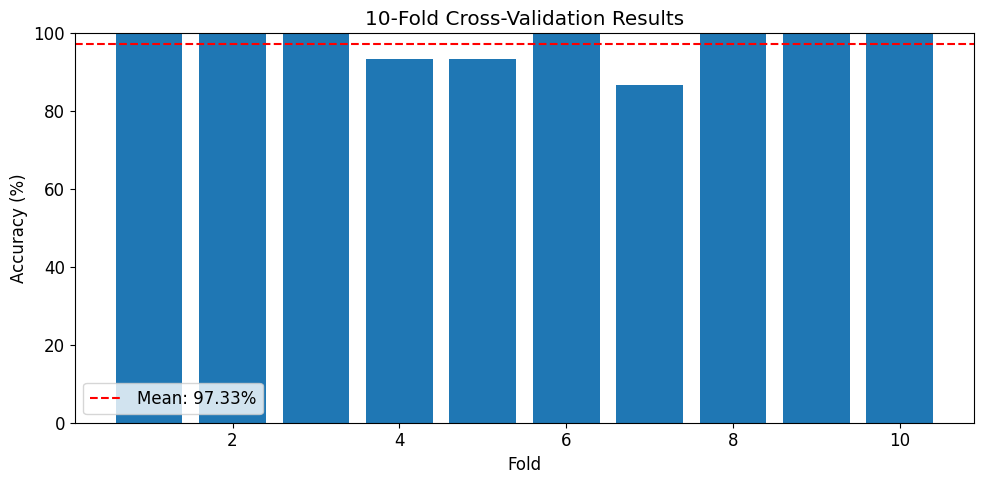

In [17]:
# Create sklearn MLP for cross-validation
# TODO: add code here to create an sklearn MLP
## Hint: see Exercise 6
sklearn_mlp_cv = MLPClassifier(
 hidden_layer_sizes=(8,), # One hidden layer with 8 neurons
 activation='logistic', # Sigmoid activation
 solver='sgd', # Stochastic gradient descent
 learning_rate_init=0.5,
 max_iter=1000,
 random_state=42
)

# 10-fold cross-validation
cv_scores = cross_val_score(sklearn_mlp_cv, X_normalised, y, cv=10)

print("10-Fold Cross-Validation Results")
print("=" * 50)
print(f"Fold scores: {cv_scores}")
print(f"\nMean accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard deviation: {cv_scores.std() * 100:.2f}%")
print(f"\n95% confidence interval: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100*1.96:.2f}%")
                                                                  
# Visualise
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), cv_scores * 100)
plt.axhline(y=cv_scores.mean() * 100, color='r', linestyle='--', label=f'Mean: {cv_scores.mean() * 100:.2f}%')
plt.xlabel('Fold')
plt.ylabel('Accuracy (%)')
plt.title('10-Fold Cross-Validation Results')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 8: Text Classification with Vector Hashing  

Apply vector hashing to classify text (based on lecture slides).

**The Vector Hashing Process**
1. **Break text into n-grams** (e.g., word pairs)
2. **Hash each n-gram** to an index using: `index = hash(n-gram) % vector_size`
3. **Create feature vector** by counting n-grams at each index
4. **Train classifier** on the feature vectors

### Task 8.1: Create Sample Dataset

Sentiment classification: positive vs negative reviews

In [18]:
# Sample dataset: Positive and negative reviews
# 40 reviews total (20 positive, 20 negative) for proper 5-fold CV
reviews = [
 # Positive reviews (label = 1)
 ("Great product, love it!", 1),
 ("Excellent quality and fast delivery", 1),
 ("Best purchase I have ever made", 1),
 ("Amazing service, highly recommend", 1),
 ("Wonderful experience, will buy again", 1),
 ("Perfect, exactly what I needed", 1),
 ("Fantastic value for money", 1),
 ("Love this product so much", 1),
 ("Absolutely brilliant, exceeded expectations", 1),
 ("Super happy with my purchase", 1),
 ("Outstanding quality and great price", 1),
 ("Highly satisfied, would recommend to friends", 1),
 ("Impressive quality, very pleased", 1),
 ("Delightful product, works perfectly", 1),
 ("Exceptional value, fast shipping too", 1),
 ("Really love it, great buy", 1),
 ("Superb quality, five stars", 1),
 ("Very impressed, excellent product", 1),
 ("Terrific purchase, highly recommend", 1),
 ("Great value, works as expected", 1),

 # Negative reviews (label = 0)
 ("Terrible, don't buy this", 0),
 ("Worst product I have ever bought", 0),
 ("Very disappointed with quality", 0),
 ("Awful experience, waste of money", 0),
 ("Poor quality, broke after one day", 0),
 ("Do not recommend this product", 0),
 ("Horrible, want my money back", 0),
 ("Bad purchase, very unhappy", 0),
 ("Complete rubbish, total disappointment", 0),
 ("Defective item, poor customer service", 0),
 ("Absolutely dreadful, avoid at all costs", 0),
 ("Useless product, completely dissatisfied", 0),
 ("Cheap quality, not worth it", 0),
 ("Disappointing purchase, broke quickly", 0),
 ("Regret buying this, poor value", 0),
 ("Frustrating experience, bad product", 0),
 ("Substandard quality, very unhappy", 0),
 ("Faulty product, terrible service", 0),
 ("Would not recommend, waste of time", 0),
 ("Inferior quality, money wasted", 0),
]
print(f"Dataset: {len(reviews)} reviews")
print(f"Positive: {sum(1 for _, l in reviews if l == 1)}")
print(f"Negative: {sum(1 for _, l in reviews if l == 0)}")

Dataset: 40 reviews
Positive: 20
Negative: 20


### Task 8.2: Implement N-gram Extraction

Extract word 2-grams (pairs of consecutive words).

In [19]:
def extract_word_ngrams(text, n=2):
    """
    Extract word n-grams from text.

    Example:
    "Great product love" -> ["Great product", "product love"]
    """
    # Clean text and split into words
    text_clean = text.lower()
    for char in [',', '!', '.', "'", '"']:
        text_clean = text_clean.replace(char, '')
    words = text_clean.split()

    # Extract n-grams
    ngrams = []
    for i in range(len(words) - n + 1):
        ngram = ' '.join(words[i:i+n])
        ngrams.append(ngram)

    return ngrams
# Test
test_text = "Great product, love it!"
print(f"Text: {test_text}")
print(f"2-grams: {extract_word_ngrams(test_text, n=2)}")

Text: Great product, love it!
2-grams: ['great product', 'product love', 'love it']


### Task 8.3: Implement Vector Hashing

Hash each n-gram to an index using: sum of ASCII values mod vector_size.

In [20]:
def hash_ngram(ngram, vector_size):
    """Hash an n-gram to an index using ASCII sum."""
    ascii_sum = sum(ord(char) for char in ngram)
    return ascii_sum % vector_size

def text_to_vector(text, vector_size=10, n=2):
    """
    Convert text to a fixed-size vector using n-gram hashing.
    """
    # Initialise vector
    vector = np.zeros(vector_size)

    # Extract n-grams and hash
    ngrams = extract_word_ngrams(text, n)
    for ngram in ngrams:
        index = hash_ngram(ngram, vector_size)
        vector[index] += 1

    return vector

# Test with example from slides
test_reviews = [
    "Great product, love it!",
    "Terrible, don't buy",
    "Okay, but not great",
]
print("Vector Hashing Examples (vector_size=10):")
print("=" * 60)
for text in test_reviews:
    ngrams = extract_word_ngrams(text, n=2)
    vec = text_to_vector(text, vector_size=10, n=2)
    print(f"\nText: {text}")
    print(f"2-grams: {ngrams}")
    for ng in ngrams:
        idx = hash_ngram(ng, 10)
        ascii_sum = sum(ord(c) for c in ng)
        print(f" '{ng}' -> ASCII sum: {ascii_sum} -> index: {idx}")
    print(f"Vector: {vec.astype(int)}")

Vector Hashing Examples (vector_size=10):

Text: Great product, love it!
2-grams: ['great product', 'product love', 'love it']
 'great product' -> ASCII sum: 1332 -> index: 2
 'product love' -> ASCII sum: 1239 -> index: 9
 'love it' -> ASCII sum: 691 -> index: 1
Vector: [0 1 1 0 0 0 0 0 0 1]

Text: Terrible, don't buy
2-grams: ['terrible dont', 'dont buy']
 'terrible dont' -> ASCII sum: 1326 -> index: 6
 'dont buy' -> ASCII sum: 805 -> index: 5
Vector: [0 0 0 0 0 1 1 0 0 0]

Text: Okay, but not great
2-grams: ['okay but', 'but not', 'not great']
 'okay but' -> ASCII sum: 799 -> index: 9
 'but not' -> ASCII sum: 700 -> index: 0
 'not great' -> ASCII sum: 900 -> index: 0
Vector: [2 0 0 0 0 0 0 0 0 1]


### Task 8.4: Create Feature Matrix and Train Classifier

Feature matrix shape: (40, 200)
Labels shape: (40, 1)

Training MLP for sentiment classification...


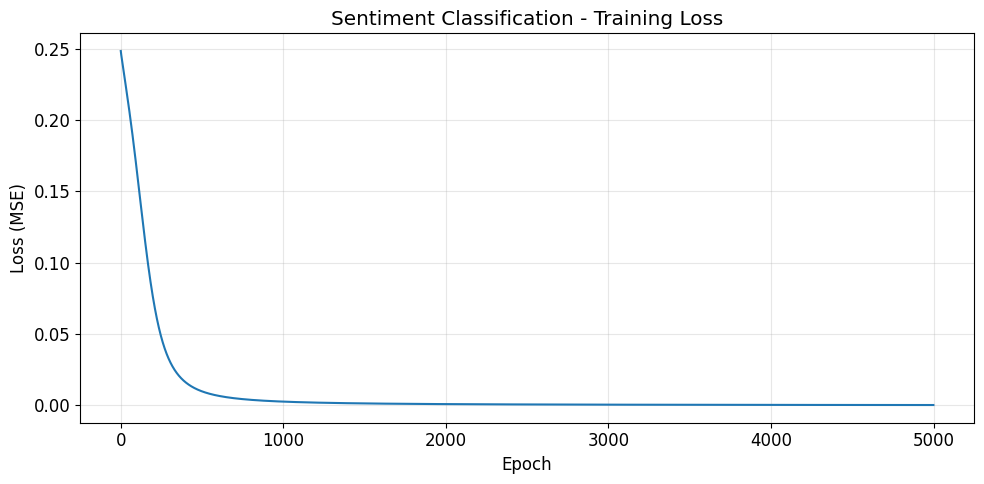


Training Set Results:
------------------------------------------------------------
Great product, love it!                    -> Positive (0.98) ✓
Excellent quality and fast delivery        -> Positive (0.99) ✓
Best purchase I have ever made             -> Positive (0.99) ✓
Amazing service, highly recommend          -> Positive (0.99) ✓
Wonderful experience, will buy again       -> Positive (0.98) ✓
Perfect, exactly what I needed             -> Positive (0.98) ✓
Fantastic value for money                  -> Positive (0.98) ✓
Love this product so much                  -> Positive (0.98) ✓
Absolutely brilliant, exceeded expectati   -> Positive (0.98) ✓
Super happy with my purchase               -> Positive (0.98) ✓
Outstanding quality and great price        -> Positive (0.99) ✓
Highly satisfied, would recommend to fri   -> Positive (0.98) ✓
Impressive quality, very pleased           -> Positive (0.98) ✓
Delightful product, works perfectly        -> Positive (0.98) ✓
Exceptional value, f

In [21]:
# Create feature matrix
vector_size = 200 # Larger for better separation
X_text = np.array([text_to_vector(text, vector_size, n=2) for text, _ in reviews])
y_text = np.array([label for _, label in reviews]).reshape(-1, 1)
print(f"Feature matrix shape: {X_text.shape}")
print(f"Labels shape: {y_text.shape}")
# Train MLP
np.random.seed(42)
# Create MLP with: vector_size inputs, 32 hidden neurons, 1 output, learning rate = 1.0
mlp_text = MLP(n_inputs=vector_size, n_hidden=32, n_outputs=1, learning_rate=1.0)
print("\nTraining MLP for sentiment classification...")
# Train MLP with 5000 epochs
losses_text = mlp_text.train(X_text, y_text, epochs=5000, verbose=False)
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses_text)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Sentiment Classification - Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Evaluate on training data
print("\nTraining Set Results:")
print("-" * 60)
correct = 0
for (text, label), x in zip(reviews, X_text):
    output = mlp_text.forward(x.reshape(1, -1))[0, 0]
    pred = 1 if output >= 0.5 else 0
    if pred == label:
        correct += 1
    sentiment = "Positive" if pred == 1 else "Negative"
    mark = "✓" if pred == label else "✗"
    print(f"{text[:40]:<42} -> {sentiment} ({output:.2f}) {mark}")
print(f"\nTraining Accuracy: {correct}/{len(reviews)} = {correct/len(reviews)*100:.1f}%")


### Task 8.5: Test on New Reviews

Test the classifier on reviews it hasn't seen

In [22]:
# These sentences reuse word pairs (2-grams) from the training data
test_reviews_new = [
    "Great product, value for money", # "great product", "value for" from training
    "Very disappointed, waste of money", # "very disappointed", "waste of" from training
    "Love it, will buy again", # "love it", "buy again" from training
    "Do not recommend, very unhappy", # "do not", "not recommend" from training
    "Excellent quality, exceeded expectations", # "excellent quality", "exceeded expectations
    "Terrible, want my money back", # "my money", "money back" from training
]
print("Testing on New Reviews:")
print("=" * 60)
for review in test_reviews_new:
    vec = text_to_vector(review, vector_size, n=2)
    output = mlp_text.forward(vec.reshape(1, -1))[0, 0]
    sentiment = "Positive" if output >= 0.5 else "Negative"
    confidence = output if output >= 0.5 else 1 - output
    print(f"\n\"{review}\"")
    print(f" -> {sentiment} (raw output: {output:.3f}, confidence: {confidence:.1%})")

Testing on New Reviews:

"Great product, value for money"
 -> Positive (raw output: 0.906, confidence: 90.6%)

"Very disappointed, waste of money"
 -> Negative (raw output: 0.022, confidence: 97.8%)

"Love it, will buy again"
 -> Positive (raw output: 0.894, confidence: 89.4%)

"Do not recommend, very unhappy"
 -> Negative (raw output: 0.001, confidence: 99.9%)

"Excellent quality, exceeded expectations"
 -> Negative (raw output: 0.146, confidence: 85.4%)

"Terrible, want my money back"
 -> Negative (raw output: 0.035, confidence: 96.5%)


### Task 8.6: ROC Curve and AUC
For binary classification, the ROC (Receiver Operating Characteristic) curve shows the trade-off between:
- **True Positive Rate (Sensitivity):** TP / (TP + FN)
- **False Positive Rate:** FP / (FP + TN)

The AUC (Area Under Curve) summarises performance: 1.0 = perfect, 0.5 = random guessing.

**Important:** To get a realistic estimate of model performance, we compute the ROC from **out-of-fold
predictions** using k-fold cross-validation. This ensures each prediction is made on data the model hasn't
seen during training.

Got 40 out-of-fold predictions from 5-fold CV
Each prediction was made when that sample was in the test fold


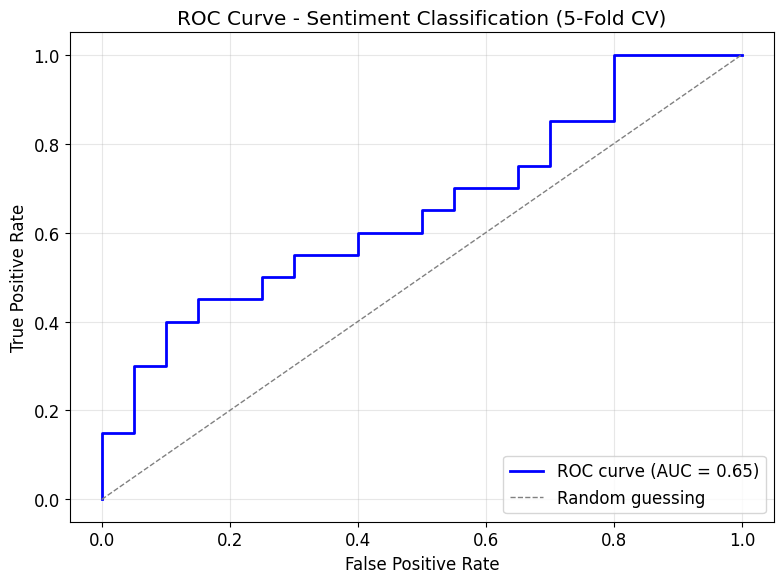


AUC Score: 0.652
AUC = 1.0 means perfect classification
AUC = 0.5 means random guessing

Note: This ROC is computed from out-of-fold predictions,
giving a realistic estimate of generalisation performance.


In [23]:
# Train sklearn MLP with 5-fold CV and plot ROC curve
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

# Prepare data (using the same features from our from-scratch implementation)
y_binary = y_text.flatten()  # Labels as 1D array

# Create sklearn MLP with adam solver (optimizer) for better convergence and:
# 32 hidden neurons, logistic activation (sigmoid),
# initial learning rate 0.01, 2000 epochs (iterations), random seed 42
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='logistic',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=2000,
    random_state=42
)

# Get out-of-fold probability predictions using 5-fold CV
# Each sample is predicted when it's in the test fold (not seen during training)
y_probs = cross_val_predict(
    sklearn_mlp,
    X_text,
    y_binary,
    cv=5,  # 5-fold cross-validation
    method='predict_proba'  # Get probabilities, not just predictions
)[:, 1]  # Probability of class 1 (positive)

print(f"Got {len(y_probs)} out-of-fold predictions from 5-fold CV")
print(f"Each prediction was made when that sample was in the test fold")

# Compute ROC curve from cross-validated predictions
fpr, tpr, thresholds = roc_curve(y_binary, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Sentiment Classification (5-Fold CV)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC Score: {roc_auc:.3f}")
print("AUC = 1.0 means perfect classification")
print("AUC = 0.5 means random guessing")
print("\nNote: This ROC is computed from out-of-fold predictions,")
print("giving a realistic estimate of generalisation performance.")

## Exercise 9: Regression

Extend the MLP to handle **regression** (predicting continuous values) instead of classification.

**Key changes for regression:**
1. **Output activation:** Use linear (identity) activation instead of sigmoid
2. **Hidden activation:** Use **tanh** instead of sigmoid (outputs in [-1, 1], better for regression)
3. **Loss function:** MSE (Mean Squared Error) remains appropriate

**Why tanh for the hidden layer?**
- Sigmoid outputs are bounded to (0, 1), limiting expressiveness
- tanh outputs are in (-1, 1), centered around 0
- tanh: `np.tanh(x)`, derivative: `1 - np.tanh(x)**2`

**Dataset:** Predict y = sin(x) for x in [0, 2π]

### Task 9.1

**Steps:**
1. Implement MLPRegressor with: 16 hidden neurons and tanh activation; linear output neuron
2. Generate training data: X = np.linspace(0, 2*np.pi, 50) , y = np.sin(X)
3. Normalise X to [0, 1] (y is already in [-1, 1], perfect for tanh)
4. Train for 5000 epochs with learning_rate=0.15
5. Plot predictions vs actual sine curve

Data: 50 points, X in [0, 2π], y = sin(x)
Normalised: X in [0, 1], y in [-1, 1]

Using tanh activation (outputs in [-1, 1]) - better for regression!

Training MLP to approximate sin(x)...
Epoch 0: MSE = 0.922684
Epoch 1000: MSE = 0.205347
Epoch 2000: MSE = 0.200930
Epoch 3000: MSE = 0.162985
Epoch 4000: MSE = 0.009329


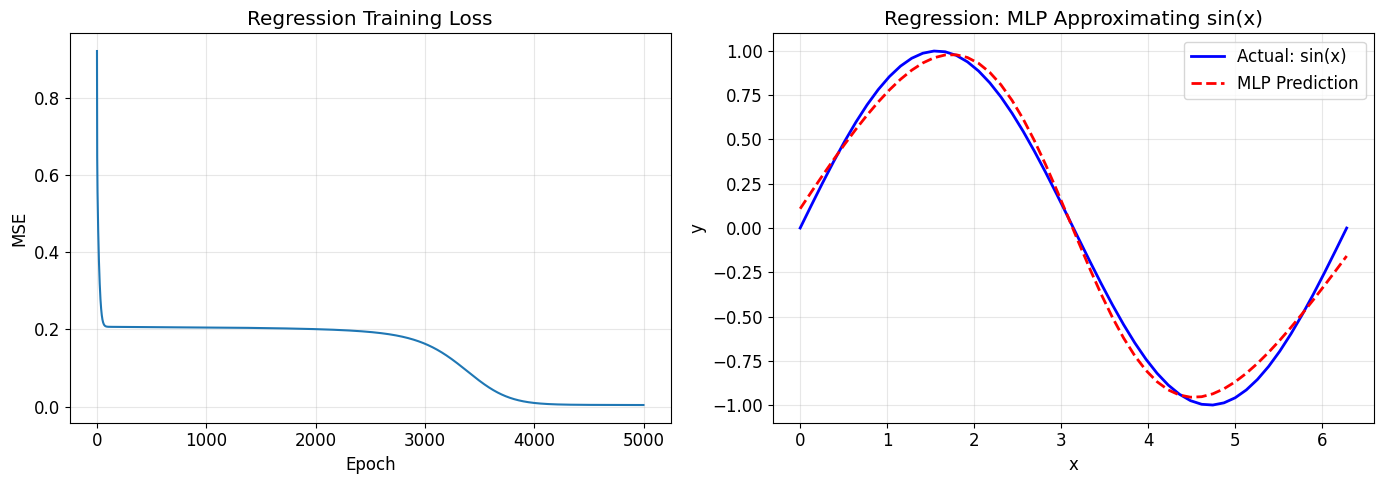


R² Score: 0.9919
(1.0 = perfect fit, 0.0 = predicting the mean)


In [24]:
class MLPRegressor:
    """
    MLP for regression with tanh hidden activation and linear output.

    Why tanh instead of sigmoid for regression?
    - Sigmoid outputs are in (0, 1), limiting expressiveness
    - tanh outputs are in (-1, 1), centered around 0
    - tanh often trains faster due to stronger gradients
    """

    def __init__(self, n_inputs, n_hidden, learning_rate=0.5):
        self.learning_rate = learning_rate

        # Xavier/Glorot initialization (better for tanh)
        limit_ih = np.sqrt(6 / (n_inputs + n_hidden))
        limit_ho = np.sqrt(6 / (n_hidden + 1))
        self.weights_ih = np.random.uniform(-limit_ih, limit_ih, (n_inputs, n_hidden))
        self.bias_h = np.zeros(n_hidden)
        self.weights_ho = np.random.uniform(-limit_ho, limit_ho, (n_hidden, 1))
        self.bias_o = np.zeros(1)

    def tanh(self, x):
        return np.tanh(x)

    def tanh_derivative(self, x):
        return 1 - np.tanh(x) ** 2

    def forward(self, X):
        # Hidden layer (tanh activation)
        self.z_h = np.dot(X, self.weights_ih) + self.bias_h
        self.a_h = self.tanh(self.z_h)

        # Output layer (LINEAR - no activation for regression)
        self.z_o = np.dot(self.a_h, self.weights_ho) + self.bias_o
        return self.z_o

    def backward(self, X, y):
        n_samples = X.shape[0]

        # Output error (linear output, derivative = 1)
        output_error = y - self.z_o

        # Hidden error (backpropagate through tanh)
        hidden_error = np.dot(output_error, self.weights_ho.T)
        hidden_delta = hidden_error * self.tanh_derivative(self.z_h)

        # Update weights
        self.weights_ho += self.learning_rate * np.dot(self.a_h.T, output_error) / n_samples
        self.bias_o += self.learning_rate * np.mean(output_error, axis=0)
        self.weights_ih += self.learning_rate * np.dot(X.T, hidden_delta) / n_samples
        self.bias_h += self.learning_rate * np.mean(hidden_delta, axis=0)

    def train(self, X, y, epochs, verbose=True):
        losses = []
        for epoch in range(epochs):
            output = self.forward(X)
            loss = np.mean((y - output) ** 2)
            losses.append(loss)
            self.backward(X, y)
            if verbose and epoch % 1000 == 0:
                print(f"Epoch {epoch}: MSE = {loss:.6f}")
        return losses

# Create sine wave data: y = sin(x) for x in [0, 2π]
np.random.seed(42)
X_reg = np.linspace(0, 2 * np.pi, 50).reshape(-1, 1)
y_reg = np.sin(X_reg)

# Normalise X to [0, 1] range (y is already in [-1, 1] which suits tanh)
X_reg_norm = X_reg / (2 * np.pi)

print(f"Data: {len(X_reg)} points, X in [0, 2π], y = sin(x)")
print(f"Normalised: X in [0, 1], y in [-1, 1]")
print("\nUsing tanh activation (outputs in [-1, 1]) - better for regression!")
# Train
print("\nTraining MLP to approximate sin(x)...")
print("=" * 50)

mlp_reg = MLPRegressor(n_inputs=1, n_hidden=16, learning_rate=0.15)
losses_reg = mlp_reg.train(X_reg_norm, y_reg, epochs=5000)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
axes[0].plot(losses_reg)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Regression Training Loss')
axes[0].grid(True, alpha=0.3)

# Predictions vs actual sine curve
y_pred_reg = mlp_reg.forward(X_reg_norm)
axes[1].plot(X_reg, y_reg, 'b-', linewidth=2, label='Actual: sin(x)')
axes[1].plot(X_reg, y_pred_reg, 'r--', linewidth=2, label='MLP Prediction')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Regression: MLP Approximating sin(x)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate R² score
ss_res = np.sum((y_reg - y_pred_reg) ** 2)
ss_tot = np.sum((y_reg - y_reg.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)
print(f"\nR² Score: {r2:.4f}")
print("(1.0 = perfect fit, 0.0 = predicting the mean)")

### Task 9.2

**Experiment:** Try learning_rate=0.5 and observe the training instability (glitches in the loss curve).

Training with learning_rate=0.5 (too high - observe instability):
Epoch 0: MSE = 0.922684
Epoch 1000: MSE = 0.118931
Epoch 2000: MSE = 0.018992
Epoch 3000: MSE = 0.018636
Epoch 4000: MSE = 0.017930


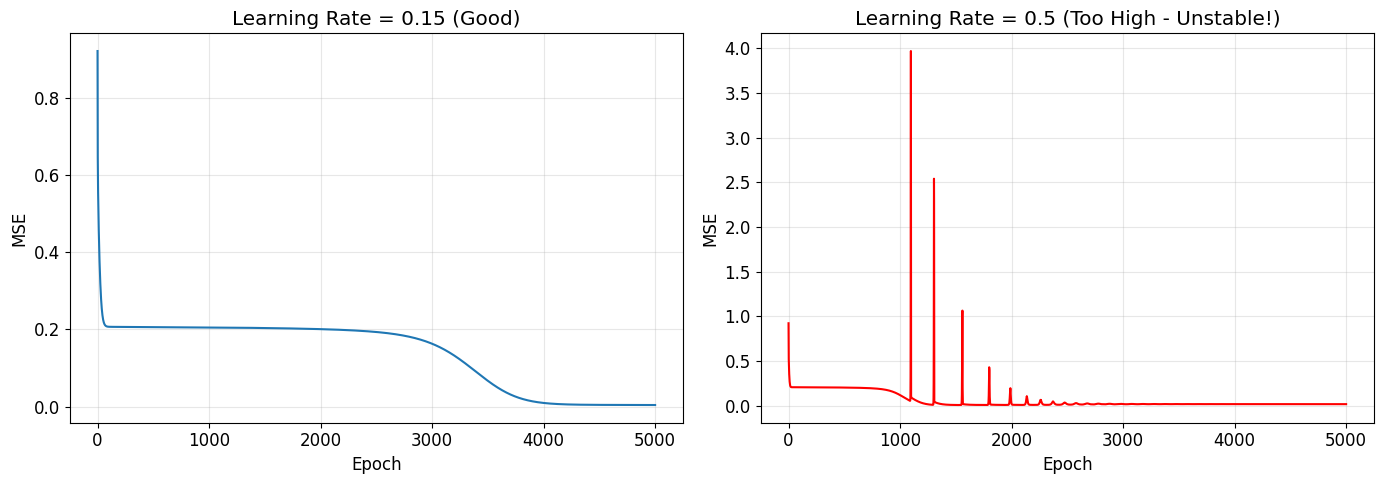


Notice the instability in the high learning rate plot!
Large weight updates can overshoot the minimum, causing oscillations or divergence.


In [25]:
print("Training with learning_rate=0.5 (too high - observe instability):")
print("=" * 50)
np.random.seed(42)
# TODO: add code here to create MLP with learning rate 0.5
## Hint: see Task 9.1
mlp_reg = MLPRegressor(n_inputs=1, n_hidden=16, learning_rate=0.5)

# TODO: add code here to train MLP
## Hint: see Task 9.1
losses_high_lr = mlp_reg.train(X_reg_norm, y_reg, epochs=5000)

# Compare the two training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(losses_reg)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Learning Rate = 0.15 (Good)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(losses_high_lr, color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].set_title('Learning Rate = 0.5 (Too High - Unstable!)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\nNotice the instability in the high learning rate plot!")
print("Large weight updates can overshoot the minimum, causing oscillations or divergence.")

## Exercise 10: Character N-grams for Language Detection

Modify the text classification to use **character n-grams** instead of word n-grams for language detection.

**Character n-grams** capture language-specific letter patterns. For example:
- **Irish:** 'bh', 'ái', 'odh', 'cht'
- **French:** ' le', 'oi ', 'eau', 'eux'
- **English:** 'the', 'ing', 'tion'

**Steps:**
1. Implement `extract_char_ngrams(text, n=4)` to extract character 4-grams
2. Use vector hashing as before (normalise by n-gram count to handle varying text lengths)
3. Create a dataset with sentences in different languages (at least 15 per language)
4. Train an sklearn `MLPClassifier` (like we did in Task 8.6)
5. Use cross-validation to evaluate performance
6. Test on new sentences

### Steps 1-3:

In [26]:
# Step 1
def extract_char_ngrams(text, n=4):
    """Extract character n-grams from text."""
    text = text.lower()
    ngrams = []
    for i in range(len(text) - n + 1):
        ngrams.append(text[i:i+n])
    return ngrams

# Step 2
def text_to_vector_char(text, vector_size=100, n=4):
    """Convert text to vector using character n-gram hashing."""
    vector = np.zeros(vector_size)
    ngrams = extract_char_ngrams(text, n)
    for ngram in ngrams:
        index = sum(ord(c) for c in ngram) % vector_size
        vector[index] += 1
    # Normalise by n-gram count to handle different sentence lengths
    if len(ngrams) > 0:
        vector = vector / len(ngrams)
    return vector

# Step 3
# Language dataset (English, French, Irish)
language_data = [
    # English (label 0)
    ("The quick brown fox jumps over the lazy dog", 0),
    ("Machine learning is a fascinating field of study", 0),
    ("The weather today is quite pleasant and warm", 0),
    ("Programming computers requires logical thinking", 0),
    ("The students are working hard on their assignments", 0),
    ("Artificial intelligence will change the world", 0),
    ("Reading books helps expand your vocabulary", 0),
    ("The mountains were covered with fresh snow", 0),
    ("She decided to learn a new language this year", 0),
    ("The conference was attended by many researchers", 0),
    ("Technology continues to advance at a rapid pace", 0),
    ("The garden was filled with beautiful flowers", 0),
    ("He completed the project ahead of schedule", 0),
    ("The library contains thousands of interesting books", 0),
    ("Swimming is excellent exercise for the whole body", 0),

    # French (label 1)
    ("Le renard brun rapide saute par-dessus le chien paresseux", 1),
    ("L'apprentissage automatique est un domaine fascinant", 1),
    ("Le temps aujourd'hui est assez agréable et chaud", 1),
    ("La programmation informatique nécessite une pensée logique", 1),
    ("Les étudiants travaillent dur sur leurs devoirs", 1),
    ("L'intelligence artificielle changera le monde", 1),
    ("La lecture des livres aide à enrichir le vocabulaire", 1),
    ("Les montagnes étaient couvertes de neige fraîche", 1),
    ("Elle a décidé d'apprendre une nouvelle langue cette année", 1),
    ("La conférence a été suivie par de nombreux chercheurs", 1),
    ("La technologie continue de progresser rapidement", 1),
    ("Le jardin était rempli de belles fleurs", 1),
    ("Il a terminé le projet avant la date prévue", 1),
    ("La bibliothèque contient des milliers de livres intéressants", 1),
    ("La natation est un excellent exercice pour tout le corps", 1),

    # Irish (label 2)
    ("Tá an aimsir go hálainn inniu agus tá sé te", 2),
    ("Is breá liom bheith ag foghlaim teangacha nua", 2),
    ("Tá na mic léinn ag obair go dian ar a gcuid oibre", 2),
    ("Athróidh an intleacht shaorga an domhan go mór", 2),
    ("Is tír álainn í Éire le cultúr saibhir agus stair", 2),
    ("Tá an Ghaeilge ina teanga bhreá le foghlaim", 2),
    ("Cabhraíonn léitheoireacht leabhar le do stór focal", 2),
    ("Bhí na sléibhte clúdaithe le sneachta úr geal", 2),
    ("Chinn sí teanga nua a fhoghlaim i mbliana", 2),
    ("D'fhreastail go leor taighdeoirí ar an gcomhdháil", 2),
    ("Leanann an teicneolaíocht ag dul chun cinn go tapa", 2),
    ("Bhí an gairdín lán de bhláthanna áille daite", 2),
    ("Chríochnaigh sé an tionscadal roimh an spriocdháta", 2),
    ("Tá na mílte leabhar suimiúil sa leabharlann mhór", 2),
    ("Is cleachtadh iontach é snámh don chorp ar fad", 2),
]
print("Language Detection Dataset")
print("=" * 50)
print(f"English: {sum(1 for _, l in language_data if l == 0)} samples")
print(f"French: {sum(1 for _, l in language_data if l == 1)} samples")
print(f"Irish: {sum(1 for _, l in language_data if l == 2)} samples")
# Show example character n-grams (now 4-grams)
print("\nExample character 4-grams:")
for lang, name in [(0, "English"), (1, "French"), (2, "Irish")]:
    text = [t for t, l in language_data if l == lang][0]
    ngrams = extract_char_ngrams(text[:30], n=4)[:5]
    print(f" {name}: {ngrams}")

Language Detection Dataset
English: 15 samples
French: 15 samples
Irish: 15 samples

Example character 4-grams:
 English: ['the ', 'he q', 'e qu', ' qui', 'quic']
 French: ['le r', 'e re', ' ren', 'rena', 'enar']
 Irish: ['tá a', 'á an', ' an ', 'an a', 'n ai']


### Steps 4-5:

In [27]:
from sklearn.neural_network import MLPClassifier
# Create feature matrix
vector_size = 100
X_lang = np.array([text_to_vector_char(text, vector_size, n=4) for text, _ in language_data])
y_lang = np.array([label for _, label in language_data]) # sklearn handles multi-class direct

print(f"Feature matrix shape: {X_lang.shape}")
print(f"Labels shape: {y_lang.shape}")

# Train sklearn MLP
# TODO: add code here to create an sklearn MLP
## Hint: see Task 8.6 (use the same hyperparameters)
mlp_lang = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='logistic',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=2000,
    random_state=42
)

print("\nTraining language detection model...")

mlp_lang.fit(X_lang, y_lang)

# Evaluate on training data
accuracy_lang = mlp_lang.score(X_lang, y_lang)

print(f"Training Accuracy: {accuracy_lang * 100:.1f}%")

# Cross-validation for realistic estimate
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(mlp_lang, X_lang, y_lang, cv=5)
print(f"5-Fold CV Accuracy: {cv_scores.mean() * 100:.1f}% (+/- {cv_scores.std() * 100:.1f}%)")

Feature matrix shape: (45, 100)
Labels shape: (45,)

Training language detection model...
Training Accuracy: 100.0%
5-Fold CV Accuracy: 73.3% (+/- 15.1%)


### Step 6:

In [28]:
# Test on new sentences
test_sentences = [
 "The students are learning programming today",
 "Les étudiants apprennent la programmation",
 "Tá na mic léinn ag foghlaim ríomhchlárú inniu",
 "Reading books helps improve vocabulary skills",
 "La lecture des livres enrichit le vocabulaire",
 "Cabhraíonn léitheoireacht leabhar le stór focal",
]

language_names = ["English", "French", "Irish"]

print("Language Detection Results:")
print("=" * 60)
for sentence in test_sentences:
 vec = text_to_vector_char(sentence, vector_size, n=4).reshape(1, -1)
 pred = mlp_lang.predict(vec)[0]
 probs = mlp_lang.predict_proba(vec)[0]
 confidence = probs[pred]
 display_sent = f'"{sentence[:50]}..."' if len(sentence) > 50 else f'"{sentence}"'
 print(f"\n{display_sent}")
 print(f" -> {language_names[pred]} (confidence: {confidence:.1%})")

Language Detection Results:

"The students are learning programming today"
 -> English (confidence: 81.0%)

"Les étudiants apprennent la programmation"
 -> French (confidence: 86.9%)

"Tá na mic léinn ag foghlaim ríomhchlárú inniu"
 -> Irish (confidence: 99.7%)

"Reading books helps improve vocabulary skills"
 -> English (confidence: 82.5%)

"La lecture des livres enrichit le vocabulaire"
 -> French (confidence: 98.8%)

"Cabhraíonn léitheoireacht leabhar le stór focal"
 -> Irish (confidence: 98.1%)


## Summary and Key Takeaways

In this lab, you have:

1. **Implemented an MLP from scratch** with sigmoid activation and backpropagation
2. **Applied data normalisation** to prepare data for neural network training
3. **Classified the Iris dataset** using your custom MLP
4. **Computed confusion matrices** and derived performance metrics
5. **Used cross-validation** for robust performance estimation
6. **Applied vector hashing** for text classification

### Key Equations

**Sigmoid activation:**
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

**Sigmoid derivative:**
$$\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))$$

**Output error gradient:**
$$\delta_k = y_k \cdot (1 - y_k) \cdot e_k$$

**Weight update:**
$$\Delta w_{jk} = \alpha \cdot y_j \cdot \delta_k$$